<a href="https://colab.research.google.com/github/DebDuttz/Training-D2/blob/main/DeepLearningD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# A recipe to turn each image into a tensor of pixel numbers
to_tensor = transforms.ToTensor()

# Download MNIST (Colab fetches it automatically)
train_data = datasets.MNIST(root="data", train=True,  download=True, transform=to_tensor)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=to_tensor)

print("Training images:", len(train_data))   # 60000
print("One image shape:", train_data[0][0].shape)  # [1, 28, 28] -> 1 colour, 28x28 pixels
print("Its label:", train_data[0][1])         # the digit it shows

Training images: 60000
One image shape: torch.Size([1, 28, 28])
Its label: 5


In [8]:
# DataLoader serves the data in shuffled batches of 64
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Peek at one batch
images, labels = next(iter(train_loader))
print("One batch of images:", images.shape)   # [64, 1, 28, 28] -> 64 images at once
print("One batch of labels:", labels.shape)   # [64]

One batch of images: torch.Size([64, 1, 28, 28])
One batch of labels: torch.Size([64])


In [11]:
import torch

# Device setup for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()           # turn 28x28 image into a row of 784 numbers
        self.layer1 = nn.Linear(784, 128)     # 784 pixels -> 128 hidden neurons
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)        # randomly ignore 20% of neurons while training
        self.layer2 = nn.Linear(128, 10)      # 128 -> 10 outputs (one per digit 0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x

model = DigitNet().to(device)
print(model)

DigitNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()   # tell the network we're training (dropout ON)

for epoch in range(3):                       # 3 full passes is plenty for MNIST
    running_loss = 0.0
    for images, labels in train_loader:      # one batch at a time
        images, labels = images.to(device), labels.to(device)

        # The same taste-test loop, per batch:
        predictions = model(images)               # 1. guess
        loss = loss_function(predictions, labels) # 2. check
        optimizer.zero_grad()                     # 3a. reset slopes
        loss.backward()                           # 3b. find downhill direction
        optimizer.step()                          # 3c. nudge the weights

        running_loss += loss.item()

    avg = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} | average error: {avg:.3f}")

Epoch 1 | average error: 0.371
Epoch 2 | average error: 0.177
Epoch 3 | average error: 0.133


In [14]:
model.eval()    # dropout OFF for testing
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predicted = model(images).argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {correct/total*100:.2f}%")   # usually ~97%

Test accuracy: 96.83%


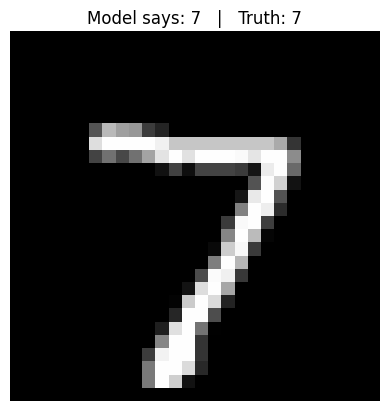

In [16]:
import matplotlib.pyplot as plt

# Grab one test image
img, true_label = test_data[0]
model.eval()
with torch.no_grad():
    guess = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Model says: {guess}   |   Truth: {true_label}")
plt.axis("off")
plt.show()